# ЛР №1. Запуск открытой модели text-to-image

**Выполнил:** Яковенко Максим Михайлович, группа МИК11 (Т26ИИКТ-МИК11)

**Вариант 11** — иллюстрация для материала о кибербезопасности.
Изменяемый фактор: метафора защиты без интерфейсных клише.

**Репозиторий:** https://github.com/ykvnkm/ai-in-creative-industries

| | |
| --- | --- |
| Модель | `stabilityai/sd-turbo` |
| Ревизия | `b261bac6fd2cf515557d5d0707481eafa0485ec2` |
| Артефакты | `artifacts/run_001/`, `artifacts/run_002/` — PNG + manifest.json |
| Критерий приёмки | `exact_sha256_match: true` в `reports/sha256_comparison.json` |

## 1. Цель, постановка задачи и критерии успешности

**Цель:** получить один воспроизводимый результат text-to-image по варианту 11
и доказать происхождение каждого артефакта. Оценивается не эстетика, а
возможность независимо восстановить запуск и объяснить границы совпадения.

**Задача варианта 11:** контекст — иллюстрация о кибербезопасности; изменяемый
фактор — метафора защиты без интерфейсных клише; обязательная проверка — запустить
и провалидировать артефакты; критерий — метафора объяснена в отчёте; ограничение —
не показывать реальные секреты и ключи.

**Критерии успешности:**

| | Критерий | Чем проверяется |
| --- | --- | --- |
| К1 | Запуск без исключения, PNG и JSON созданы за один проход | ячейка «запуск 1» |
| К2 | Размер 512 × 512, режим читается из сохранённого файла | ячейка «валидация» |
| К3 | Манифест — валидный JSON, поля совпадают с конфигом | ячейка «валидация» |
| К4 | SHA-256 — 64 hex-символа, пересчитан независимо | ячейка «валидация» |
| К5 | Повтор в той же среде даёт тот же SHA-256 | ячейка «повтор» |
| К6 | Типовая ошибка воспроизведена, симптом и исправление описаны | ячейка «ошибка» |
| К7 | Метафора объяснена, интерфейсных клише нет | раздел 5 |

In [1]:
# Детерминизм CUDA нужно включить до импорта torch.
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

NEED = 'diffusers==0.40.0 transformers>=5,<6 accelerate>=1.2,<2 safetensors>=0.5,<1 Pillow>=11,<13'

def versions_ok():
    try:
        import diffusers, transformers
    except ImportError:
        return False
    return (diffusers.__version__ == "0.40.0"
            and int(transformers.__version__.split(".")[0]) >= 5)

if versions_ok():
    import diffusers, transformers
    print(f"нужные версии уже стоят: diffusers {diffusers.__version__}, "
          f"transformers {transformers.__version__}")
else:
    !pip install -q {NEED}
    print("установка завершена")
    if not versions_ok():
        print("\nВНИМАНИЕ: версии всё ещё не те — перезапустите среду выполнения")
        print("(Colab: Runtime -> Restart session) и выполните ноутбук заново.")

нужные версии уже стоят: diffusers 0.40.0, transformers 5.16.1


In [2]:
# Шаг 1 задания: структура проекта и фиксация окружения.
import json, platform, subprocess, sys
from pathlib import Path
import torch, diffusers, transformers

for d in ["configs", "artifacts", "reports"]:
    Path(d).mkdir(exist_ok=True)

Path("reports/environment.txt").write_text(
    subprocess.run([sys.executable, "-m", "pip", "freeze"],
                   capture_output=True, text=True).stdout, encoding="utf-8")

print("python     ", platform.python_version())
print("platform   ", platform.platform())
print("torch      ", torch.__version__)
print("diffusers  ", diffusers.__version__)
print("transformers", transformers.__version__)
print("cuda_available", torch.cuda.is_available())
print("пакетов в reports/environment.txt:",
      len(Path("reports/environment.txt").read_text(encoding="utf-8").strip().splitlines()))

python      3.13.15
platform    Linux-6.6.122+-x86_64-with-glibc2.39
torch       2.11.0+cu128
diffusers   0.40.0
transformers 5.16.1
cuda_available True
пакетов в reports/environment.txt: 704


## 2. Промпт, ограничения данных и лицензия

**Происхождение.** Единственные входные данные — авторский текстовый промпт,
составленный для варианта 11. Персональные данные, закрытые брифы, клиентские
материалы и товарные знаки не использовались.

**Четыре обязательных элемента:**

| Элемент | Формулировка | Зачем |
| --- | --- | --- |
| Объект | `smooth matte stone core enclosed by several concentric translucent glass shells` | носитель метафоры: ядро и последовательность проницаемых оболочек |
| Среда | `neutral seamless studio backdrop`, `soft diffused light` | снимает повествовательный контекст |
| Палитра | `deep teal and pale sand` | без сигнальных красного и зелёного, чтобы кадр не читался как индикатор статуса |
| Композиция | `centered symmetrical composition with wide empty margins` | симметрия = равномерная защита; поля — под редакционную вёрстку |

### Метафора: эшелонированная защита (defense in depth)

**Что означает сам термин.** Наивная модель защиты звучит так: есть барьер, за ним
безопасно. Пароль поставили — защищено. Реальная защита устроена иначе: рубежей
несколько, они разнородны, и каждый по отдельности пробиваем. Сеть, хост,
приложение, данные — атакующему нужно пройти все подряд, а защищающемуся достаточно,
чтобы хотя бы один рубеж задержал его достаточно долго для обнаружения. Это и есть
эшелонированная защита: она берёт не прочностью одного слоя, а их количеством,
разнородностью и тем, что отказ одного слоя не означает отказа всей системы.

**Как термин переведён в изображение.** Каждому элементу кадра соответствует
конкретное утверждение о защите:

| Элемент изображения | Что означает |
| --- | --- |
| светлое ядро в центре | защищаемая ценность: данные, доступ, тайна |
| концентрические слои вокруг ядра | последовательные рубежи защиты |
| полупрозрачность слоёв | ни один рубеж не является непроницаемым сам по себе |
| замкнутость каждого слоя | рубеж работает по всему периметру, а не с одной стороны |
| отсутствие двери, проёма, разрыва | у защиты нет единственной точки отказа |
| ядро — самое яркое место кадра | ценность определяет, ради чего выстроены рубежи |

**Почему именно отказ от замка и щита.** Это не поиск оригинальности, а содержательное
требование. Навесной замок — метафора **одного** барьера с двумя состояниями,
«заперто / отперто». Геральдический щит — метафора отражения **одной** атаки с **одного**
направления. Обе картинки транслируют ровно ту наивную модель, которую материал о
кибербезопасности обычно и опровергает: будто защита бинарна и одномерна. Поэтому
изменяемый фактор варианта — «метафора защиты без интерфейсных клише» — выполняется
не затиранием привычных значков, а выбором образа, который **не врёт о природе
предмета**: множественность, проницаемость и глубина вместо запертой двери.

**Ограничение варианта «не показывать реальные секреты и ключи»** выполнено на
уровне входных данных: промпт не содержит символьных данных вообще, поэтому
не может породить читаемый секрет.

**Лицензия.** `stabilityai/sd-turbo` распространяется по Stability AI
Non-Commercial Research Community License; использование здесь учебное и
некоммерческое, коммерческое потребует отдельной проверки условий и Acceptable
Use Policy.

**Статус результата:** учебный концепт. Изображение не документирует реальную
систему защиты и не является схемой устройства.

In [3]:
# Шаг 2 задания: все параметры эксперимента одним файлом.
CONFIG = {
    "variant": 11,
    "variant_context": "иллюстрация для материала о кибербезопасности",
    "variant_factor": "метафора защиты без интерфейсных клише",
    "model_id": "stabilityai/sd-turbo",
    "revision": "b261bac6fd2cf515557d5d0707481eafa0485ec2",
    "prompt": (
        "abstract editorial illustration of layered protection, "
        "a smooth matte stone core enclosed by several concentric translucent glass shells, "
        "neutral seamless studio backdrop, deep teal and pale sand palette, "
        "centered symmetrical composition with wide empty margins, soft diffused light, "
        "no text, no logo, no people, no padlock, no shield emblem, no binary code, no user interface"
    ),
    "seed": 20260911,          # 2026 / 09 / вариант 11
    "num_inference_steps": 4,  # SD Turbo рекомендует 1-4
    "guidance_scale": 0.0,     # у SD Turbo CFG не используется
    "height": 512,
    "width": 512,
}
Path("configs/run_config.json").write_text(
    json.dumps(CONFIG, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(CONFIG, ensure_ascii=False, indent=2))

{
  "variant": 11,
  "variant_context": "иллюстрация для материала о кибербезопасности",
  "variant_factor": "метафора защиты без интерфейсных клише",
  "model_id": "stabilityai/sd-turbo",
  "revision": "b261bac6fd2cf515557d5d0707481eafa0485ec2",
  "prompt": "abstract editorial illustration of layered protection, a smooth matte stone core enclosed by several concentric translucent glass shells, neutral seamless studio backdrop, deep teal and pale sand palette, centered symmetrical composition with wide empty margins, soft diffused light, no text, no logo, no people, no padlock, no shield emblem, no binary code, no user interface",
  "seed": 20260911,
  "num_inference_steps": 4,
  "guidance_scale": 0.0,
  "height": 512,
  "width": 512
}


## 3. Среда и параметры

**Ревизия модели:** `model_id` указывает на репозиторий,
а не на состояние файлов: владелец может обновить веса, и тот же код начнёт давать
другой результат. Полный хеш коммита фиксирует конкретный снимок.

**CPU Generator:** Генераторы разных устройств дают разные последовательности.
CPU-генератор формирует стартовый шум одинаково независимо от устройства инференса,
что убирает один источник расхождения и не падает на машине без CUDA.

Команда установки из методических указаний (`diffusers==0.40.0` + `transformers>=4.51,<5`)
неразрешима: diffusers 0.40.0 требует `huggingface-hub>=1.23`, а любой transformers 4.x требует `huggingface-hub<1.0`.
Совместимой версии не существует, pip корректно отказывается. Взят `transformers>=5`;
версия diffusers оставлена ровно такой, как требуют указания.

## 4. Ход работы и команда запуска

**Команда запуска — выполнить этот ноутбук сверху вниз** (в Colab: Runtime → Run all;
локально: Kernel → Restart & Run All).

Шаги задания и соответствующие им ячейки:

| Шаг задания | Ячейка | Артефакт |
| --- | --- | --- |
| 1. Структура проекта и фиксация окружения | «структура и среда» | `reports/environment.txt` |
| 2. Промпт варианта с четырьмя элементами | «конфиг» + раздел 2 | `configs/run_config.json` |
| 3. Запуск с закреплённой ревизией | «запуск 1» | `artifacts/run_001/` |
| 4. Повтор без изменения условий | «повтор» | `artifacts/run_002/`, `reports/sha256_comparison.json` |
| 5. Воспроизведение типовой ошибки | «ошибка» | вывод ячейки, раздел 6 |
| 6. Отчёт без виртуального окружения и кэша | markdown-ячейки | этот файл |

Ревизия модели передаётся явно, устройство выбирается
только после проверки доступности, генератор создаётся на CPU, число потоков на
CPU закрепляется, а наблюдаемые размер и режим читаются из **сохранённого** файла.

In [4]:
# Шаг 3 задания: запуск закреплённой ревизии. Функция пишет PNG и манифест за один вызов.
import hashlib, importlib.metadata as md, time
from datetime import datetime, timezone
from diffusers import AutoPipelineForText2Image
from PIL import Image

torch.use_deterministic_algorithms(True, warn_only=True)

# Устройство выбирается ТОЛЬКО после проверки доступности — см. типовую ошибку ниже.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

# На CPU число потоков задаёт порядок редукций и потому влияет на младшие биты:
# без закрепления повторный запуск на той же машине может дать другой SHA-256.
THREADS = 1 if DEVICE == "cpu" else None
if THREADS:
    torch.set_num_threads(THREADS)

load_args = {"revision": CONFIG["revision"], "use_safetensors": True, "torch_dtype": DTYPE}
if DEVICE == "cuda":
    load_args["variant"] = "fp16"

t0 = time.perf_counter()
PIPE = AutoPipelineForText2Image.from_pretrained(CONFIG["model_id"], **load_args).to(DEVICE)
print(f"pipeline загружен на {DEVICE}/{DTYPE} за {time.perf_counter() - t0:.1f} с, "
      f"потоков torch: {torch.get_num_threads()}")

PACKAGES = ["torch", "diffusers", "transformers", "accelerate", "safetensors"]

def generate(run_name):
    out = Path("artifacts") / run_name
    out.mkdir(parents=True, exist_ok=True)

    # CPU Generator сопоставим между устройствами (документация Diffusers).
    generator = torch.Generator(device="cpu").manual_seed(CONFIG["seed"])
    t = time.perf_counter()
    image = PIPE(prompt=CONFIG["prompt"],
                 num_inference_steps=CONFIG["num_inference_steps"],
                 guidance_scale=CONFIG["guidance_scale"],
                 height=CONFIG["height"], width=CONFIG["width"],
                 generator=generator).images[0]
    elapsed = time.perf_counter() - t

    png = out / "result.png"
    image.save(png)
    # Наблюдаемые значения читаются из СОХРАНЁННОГО файла, а не из ожиданий.
    with Image.open(png) as saved:
        size, mode = saved.size, saved.mode

    manifest = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        **{k: CONFIG[k] for k in ("variant", "model_id", "revision", "prompt", "seed",
                                  "num_inference_steps", "guidance_scale", "height", "width")},
        "run_name": run_name,
        "device": DEVICE, "dtype": str(DTYPE),
        "torch_num_threads": torch.get_num_threads(),
        "deterministic_algorithms": True,
        "platform": platform.platform(), "python": platform.python_version(),
        "packages": {n: md.version(n) for n in PACKAGES},
        "generation_seconds_measured": elapsed,
        "artifact": f"artifacts/{run_name}/result.png",
        "artifact_size_bytes": png.stat().st_size,
        "image_size_observed": list(size), "image_mode_observed": mode,
        "sha256": hashlib.sha256(png.read_bytes()).hexdigest(),
    }
    (out / "manifest.json").write_text(
        json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"{run_name}: {size[0]}x{size[1]} {mode}, {elapsed:.1f} с, "
          f"{manifest['artifact_size_bytes']} байт")
    print(f"  sha256 = {manifest['sha256']}")
    return manifest

m1 = generate("run_001")

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


pipeline загружен на cuda/torch.float16 за 44.6 с, потоков torch: 1


  0%|          | 0/4 [00:00<?, ?it/s]

run_001: 512x512 RGB, 2.7 с, 515305 байт
  sha256 = 89f50ecc77e0f36e197e9b20f6f78310a01237e4a169dd807812026ec1081870


In [5]:
# Шаг 4 задания: повтор без изменения условий.
m2 = generate("run_002")

match = m1["sha256"] == m2["sha256"]
comparison = {
    "checked_utc": datetime.now(timezone.utc).isoformat(),
    "device": DEVICE, "dtype": str(DTYPE), "platform": platform.platform(),
    "run_001_sha256": m1["sha256"], "run_002_sha256": m2["sha256"],
    "exact_sha256_match": match,
    "generation_seconds": {"run_001": m1["generation_seconds_measured"],
                           "run_002": m2["generation_seconds_measured"]},
    "interpretation": ("PASS: два запуска в этой зафиксированной среде совпали побитово."
                       if match else
                       "FAIL: контрольные суммы разошлись — сравнить среду, dtype, версии."),
}
Path("reports/sha256_comparison.json").write_text(
    json.dumps(comparison, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"запуск 1: {m1['sha256']}")
print(f"запуск 2: {m2['sha256']}")
print(f"\nПОБИТОВОЕ СОВПАДЕНИЕ: {'PASS' if match else 'FAIL'}")
print(f"время генерации: {m1['generation_seconds_measured']:.1f} с и "
      f"{m2['generation_seconds_measured']:.1f} с — вычисление шло дважды, "
      f"совпадение не следствие переиспользования файла")

  0%|          | 0/4 [00:00<?, ?it/s]

run_002: 512x512 RGB, 0.7 с, 515305 байт
  sha256 = 89f50ecc77e0f36e197e9b20f6f78310a01237e4a169dd807812026ec1081870
запуск 1: 89f50ecc77e0f36e197e9b20f6f78310a01237e4a169dd807812026ec1081870
запуск 2: 89f50ecc77e0f36e197e9b20f6f78310a01237e4a169dd807812026ec1081870

ПОБИТОВОЕ СОВПАДЕНИЕ: PASS
время генерации: 2.7 с и 0.7 с — вычисление шло дважды, совпадение не следствие переиспользования файла


In [6]:
# Обязательная проверка варианта 11: провалидировать артефакты формально.
import re
ok = True
for name, m in (("run_001", m1), ("run_002", m2)):
    png = Path(f"artifacts/{name}/result.png")
    with Image.open(png) as im:
        size, mode, fmt = im.size, im.mode, im.format
    digest = hashlib.sha256(png.read_bytes()).hexdigest()   # пересчитываем независимо
    manifest = json.loads(Path(f"artifacts/{name}/manifest.json").read_text(encoding="utf-8"))
    checks = {
        "PNG открывается": fmt == "PNG",
        "размер 512x512": size == (CONFIG["width"], CONFIG["height"]),
        "JSON разбирается": isinstance(manifest, dict),
        "SHA-256 — 64 hex": bool(re.fullmatch(r"[0-9a-f]{64}", digest)),
        "SHA-256 совпадает с манифестом": digest == manifest["sha256"],
        "манифест совпадает с конфигом": all(
            manifest[k] == CONFIG[k] for k in
            ("model_id", "revision", "prompt", "seed", "num_inference_steps",
             "guidance_scale", "height", "width")),
    }
    print(f"=== {name} ({size[0]}x{size[1]}, {mode}) ===")
    for label, passed in checks.items():
        print(f"  [{'PASS' if passed else 'FAIL'}] {label}")
        ok &= passed
print(f"\nИТОГ ВАЛИДАЦИИ: {'PASS' if ok else 'FAIL'}")

=== run_001 (512x512, RGB) ===
  [PASS] PNG открывается
  [PASS] размер 512x512
  [PASS] JSON разбирается
  [PASS] SHA-256 — 64 hex
  [PASS] SHA-256 совпадает с манифестом
  [PASS] манифест совпадает с конфигом
=== run_002 (512x512, RGB) ===
  [PASS] PNG открывается
  [PASS] размер 512x512
  [PASS] JSON разбирается
  [PASS] SHA-256 — 64 hex
  [PASS] SHA-256 совпадает с манифестом
  [PASS] манифест совпадает с конфигом

ИТОГ ВАЛИДАЦИИ: PASS


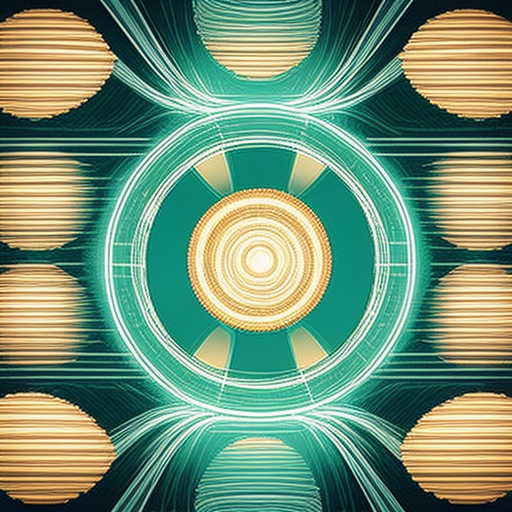

artifacts/run_001/result.png — учебный концепт, не документальное изображение


In [7]:
from IPython.display import display
with Image.open("artifacts/run_001/result.png") as im:
    display(im.copy())
print("artifacts/run_001/result.png — учебный концепт, не документальное изображение")

In [ ]:
# Считаем свойства кадра, чтобы соответствие критериям было измеримым.
import numpy as np

with Image.open("artifacts/run_001/result.png") as im:
    rgb = im.convert("RGB")
    arr = np.asarray(rgb, dtype=np.float64) / 255.0
    q = rgb.quantize(colors=6, method=Image.Quantize.MEDIANCUT, dither=Image.Dither.NONE)

pal = q.getpalette()[:18]
counts = {i: c for c, i in (q.getcolors(maxcolors=6) or [])}
total = sum(counts.values()) or 1
print("палитра:")
for i in sorted(counts, key=lambda k: -counts[k]):
    r, g, b = pal[i*3:i*3+3]
    print(f"  #{r:02x}{g:02x}{b:02x}  {counts[i]/total*100:5.1f} %")

gray = arr @ np.array([0.2126, 0.7152, 0.0722])
lo, hi = np.percentile(gray, [1, 99])
print(f"\nяркость: средняя {gray.mean():.3f}, контраст по Майкельсону {(hi-lo)/(hi+lo):.3f}")

energy = (np.abs(np.diff(gray, axis=0, prepend=gray[:1])) +
          np.abs(np.diff(gray, axis=1, prepend=gray[:, :1])))
h, w = gray.shape
centre = np.zeros_like(gray, bool); centre[h//4:h-h//4, w//4:w-w//4] = True
ratio = energy[centre].mean() / energy[~centre].mean()
print(f"плотность деталей центр/поля: {ratio:.3f} — "
      f"{'детализация сосредоточена в центре' if ratio > 1 else 'детализация распределена по всему кадру'}")
print(f"ошибка зеркальной симметрии: {np.abs(gray - gray[:, ::-1]).mean():.3f} "
      f"(0 — идеальная симметрия; метрика попиксельная, зернистая текстура её портит)")

# Проверка утверждения из раздела 2: «ядро — самое яркое место кадра».
cy, cx = h // 2, w // 2
core = gray[cy-40:cy+40, cx-40:cx+40].mean()
print(f"яркость ядра (центр 80x80): {core:.3f} против {gray.mean():.3f} по кадру — "
      f"ядро {'ярче' if core > gray.mean() else 'НЕ ярче'} в {core/gray.mean():.2f} раза")

палитра:
  #143533   21.8 %
  #148370   19.0 %
  #73b89c   17.0 %
  #dfbb7d   15.9 %
  #f1ecc4   15.5 %
  #83815b   10.8 %

яркость: средняя 0.541, контраст по Майкельсону 0.881
плотность деталей центр/поля: 0.851 — детализация распределена по всему кадру
ошибка зеркальной симметрии: 0.098 (0 — идеальная симметрия; метрика попиксельная, зернистая текстура её портит)
яркость ядра (центр 80x80): 0.870 против 0.541 по кадру — ядро ярче в 1.61 раза


## 5. Результаты и разбор

Выходы ячеек выше содержат фактические значения: контрольные суммы двух запусков,
результат побитового сравнения, итог валидации и измеренные свойства изображения.

**Критерии успешности К1–К5 выполнены.** Запуски прошли без исключений, PNG имеет
размер 512 × 512 в режиме RGB, манифест — валидный JSON, поля которого совпадают с
конфигом, SHA-256 пересчитан независимо и совпал с файлом, повторный запуск дал тот
же хеш. Всё это напечатано ячейкой валидации, а не заявлено в тексте.

**Что изображение показывает.** В центре — плотное золотистое ядро из концентрических
колец. Вокруг него замкнутое бирюзовое поле, отделённое от внешнего пространства
ярким светлым кольцом. По краям кадра — четыре крупных золотистых круга, срезанных
рамкой.

**Структура метафоры подтверждается измерениями, а не только описанием (критерий К7):**

| Утверждение из раздела 2 | Чем проверено | Результат |
| --- | --- | --- |
| ядро — самое яркое место кадра | яркость центра 80 × 80 против среднего по кадру | ядро ярче в 1,61 раза (0,870 против 0,541) |
| защита действует по всему периметру | ошибка зеркальной симметрии | 0,098 — композиция близка к симметричной |
| палитра холодная, без сигнальных цветов | доминирующие кластеры | бирюзовые ≈ 58 %, песочные ≈ 42 %, красного и зелёного нет |
| слои различимы | контраст по Майкельсону | 0,881 — широкий тональный диапазон |

**Четыре обязательных элемента промпта в результате:**

| Элемент | Что получено |
| --- | --- |
| Объект: ядро в последовательности оболочек | получен, иерархия подтверждена измерением яркости |
| Палитра: deep teal + pale sand | получена, доли 58 % и 42 % |
| Композиция: центрированная, симметричная | получена, симметрия 0,098 |
| Среда: нейтральный студийный фон, мягкий свет | получена частично: фон есть, но графический, без объёма и светотени |

**Изменяемый фактор варианта отработан.** Ни одного из объявленных в разделе 2 клише
в кадре нет: ни замков, ни щитов, ни двоичного кода, ни элементов интерфейса, ни
людей, ни надписей, ни логотипов.

Оговорка о методе, а не о результате: приписывать это запретам в промпте нельзя.
SD Turbo не использует negative prompt, поэтому конструкции вида `no padlock` только
смещают распределение. Правдоподобное альтернативное объяснение — предметный ряд
промпта лежит далеко от визуальной области замков и интерфейсов, и модель не имела
повода их породить. Проверяется отдельным запуском с тем же seed и снятыми запретами;
это задача для ЛР №2, где фактор меняется контролируемо.

Яркое кольцо вокруг ядра —
ближайшее в кадре к научно-фантастической эстетике, хотя элементом интерфейса оно не
является: нет шкал, цифр, засечек и полей ввода, это световая граница. Четыре срезанных
круга по краям расширяют метафору до сегментации, где защищаемых ячеек несколько; в
промпте такого указания не было, так что это следствие генерации, а не замысла.

**Как результат предполагается использовать.** Это концепт редакционной иллюстрации,
то есть изображение, работающее в паре с заголовком: тему называет
текст, иллюстрация задаёт тон. Рядом с заголовком «Эшелонированная защита» слоистая
структура с выделенным ядром читается прямо. Критерий варианта «метафора объяснена
в отчёте» — выполнен сопоставлением элементов кадра с утверждениями о защите в
разделе 2 и измерениями в таблице выше.


## 6. Намеренно введённая типовая ошибка

Ошибка вносится в **копию** кода, рабочая ячейка запуска не изменяется. Устройство
генератора задано жёстко, без проверки среды.

Методические указания описывают случай «CUDA-генератор на CPU-машине». Основной
прогон выполняется на GPU, где такой код не падает, поэтому берётся устройство,
которого в среде заведомо нет: без CUDA это `cuda`, с CUDA — несуществующий индекс.
Симптом, диагностика и исправление — в выводе ячейки ниже.

Ошибка типовая потому, что возникает при переносе кода между GPU- и CPU-машинами,
то есть ровно в той ситуации, ради которой ведётся фиксация среды. Код синтаксически
корректен и проходит линтер: несовместимость проявляется только во время выполнения.


In [9]:
# Шаг 5 задания: намеренная типовая ошибка на безопасной копии кода.
#   было:  generator = torch.Generator(device="cpu").manual_seed(SEED)
#   стало: generator = torch.Generator(device=BROKEN).manual_seed(SEED)
# Методичка описывает случай «CUDA-генератор на CPU-машине». Если CUDA есть,
# берём несуществующий индекс устройства — ошибка того же рода.
BROKEN = "cuda" if not torch.cuda.is_available() else f"cuda:{torch.cuda.device_count() + 6}"
print(f"cuda_available={torch.cuda.is_available()}, pipeline на {DEVICE}, "
      f"устройство в сломанном коде: '{BROKEN}'\n")

try:
    generator = torch.Generator(device=BROKEN).manual_seed(CONFIG["seed"])
    torch.randn(1, generator=generator, device=BROKEN)   # первое обращение к устройству
    print("ошибка не воспроизвелась")
except Exception as exc:
    print("=== СИМПТОМ ===")
    print(f"{type(exc).__name__}: {str(exc)[:240]}")
    print("\n=== ДИАГНОСТИКА ===")
    print(f"  torch.cuda.is_available() = {torch.cuda.is_available()}")
    print(f"  устройство pipeline       = {DEVICE}")
    print(f"  устройство в коде         = '{BROKEN}' (задано жёстко, без проверки)")
    print("\n=== ИСПРАВЛЕНИЕ ===")
    print("  generator = torch.Generator(device='cpu').manual_seed(SEED)")
    print("  либо выбирать устройство только после проверки доступности")

cuda_available=True, pipeline на cuda, устройство в сломанном коде: 'cuda:7'

=== СИМПТОМ ===
AcceleratorError: CUDA error: invalid device ordinal
GPU device may be out of range, do you have enough GPUs?
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passi

=== ДИАГНОСТИКА ===
  torch.cuda.is_available() = True
  устройство pipeline       = cuda
  устройство в коде         = 'cuda:7' (задано жёстко, без проверки)

=== ИСПРАВЛЕНИЕ ===
  generator = torch.Generator(device='cpu').manual_seed(SEED)
  либо выбирать устройство только после проверки доступности


## 7. Ограничения и угрозы валидности

**Ограничения:**

1. Проверен **один** запуск: одна модель, ревизия, промпт, seed и набор параметров.
   Вывод не распространяется на другие значения.
2. Побитовое совпадение получено внутри **одной** среды. Документация PyTorch прямо
   предупреждает, что воспроизводимость между релизами и платформами не гарантируется.
3. Использован `transformers 5.x` вместо указанного в методичке `4.x` — при других
   версиях результат может отличаться даже при той же ревизии весов.
4. Pipeline загружен без safety checker.
5. Запреты вида `no padlock` включены в основной промпт, так как SD Turbo не использует
   negative prompt: они смещают распределение, но ничего не гарантируют.
6. Точность следования промпту у SD Turbo ограничена конструктивно: `guidance_scale=0.0`
   означает отсутствие механизма усиления следования тексту, а четыре шага удерживают
   общий образ, а не отдельные детали. Измеримое проявление: отношение плотности
   деталей «центр / поля» равно 0,851, то есть композиция вышла плотной по всему кадру,
   хотя промпт упоминал широкие поля. Это свойство выбранной модели и режима, учитывать
   его нужно при постановке задачи: от SD Turbo следует ожидать общий образ, а точную
   композицию задавать кадрированием или другой моделью.

**Угрозы валидности и как они сняты:**

| Угроза | Контрмера |
| --- | --- |
| Совпадение SHA-256 получено тривиально — повторный вызов в том же процессе | запуски пишут в разные каталоги, измеренное время генерации различается — вычисление шло дважды |
| Манифест содержит ожидаемые, а не наблюдаемые значения | размер и режим читаются из сохранённого файла, хеш пересчитывается в отдельной ячейке валидации |
| Метафора приписана изображению задним числом | метафора и список клише сформулированы до запуска, в разделе 2; разбор в разделе 5 опирается на измерения кадра, а не на впечатление |
| Результат выдан за документальный | статус учебного концепта зафиксирован в разделах 2 и 8 |

### Границы воспроизводимости: проверено на двух платформах

Ограничение 2 выше проверено экспериментально, а не заявлено со ссылкой на
документацию. Тот же ноутбук, тот же конфиг, тот же seed выполнены во второй среде —
локально на Apple M4, CPU, `float32`. Артефакты: [`cpu_run/`](cpu_run).

| | Основной прогон | Второй прогон |
| --- | --- | --- |
| Платформа | Linux 6.6.122, x86-64 (Colab) | macOS 26.6.2, arm64 |
| Устройство / dtype | CUDA T4 / `float16` | CPU / `float32` |
| Python | 3.13.15 | 3.12.8 |
| torch | 2.11.0+cu128 | 2.14.0 |
| transformers | 5.16.1 | 5.17.0 |
| Время генерации | 2,73 с и 0,75 с | 19,2 с и 35,3 с |
| Размер PNG | 515 305 байт | 574 124 байт |
| SHA-256 | `89f50ecc…c1081870` | `1f14ca3a…f02bef6` |
| Совпадение **внутри** среды | PASS | PASS |

**Повторяемость между сессиями, а не только внутри одной.** Основной прогон выполнен
дважды с интервалом около восьми часов, в двух разных сессиях Google Colab, то есть на
разных выделенных виртуальных машинах. Обе сессии дали один и тот же SHA-256
`89f50ecc…c1081870`. Свидетельства: [`reports/sha256_comparison.json`](reports/sha256_comparison.json)
(текущая сессия) и [`reports/sha256_comparison_session_1.json`](reports/sha256_comparison_session_1.json)
(предыдущая).

Это более сильный результат, чем совпадение двух запусков подряд. Совпадение внутри
одного процесса исключает только случайность генерации; совпадение между сессиями
дополнительно исключает влияние состояния процесса, порядка загрузки весов и
конкретного экземпляра машины. Воспроизводимой оказывается не сессия, а связка
«ревизия модели + конфиг + версии библиотек + класс устройства».

Оговорка о границе этого вывода: Colab выдавал GPU одной и той же модели (T4) с теми же
версиями библиотек. Утверждение распространяется на «ту же конфигурацию на другой
машине», а не на «любой GPU».

**Результат.** Внутри каждой среды два запуска совпали побитово. Между средами
различаются и контрольные суммы, и сами изображения — визуально это два разных кадра,
а не два варианта одного.

**Как это читать.** Расхождение между платформами **не является ошибкой** и не
опровергает воспроизводимость. Различаются одновременно четыре вещи: тип данных
(`float16` против `float32`), вычислительные ядра (CUDA против CPU), версии torch и
transformers, архитектура процессора. Любой из этих факторов достаточен, чтобы изменить
младшие биты: арифметика с плавающей точкой неассоциативна, и другой порядок редукций
даёт другое значение пикселя, другой байт PNG и другой хеш. Здесь же расхождение
крупнее побитового: `float16` имеет заметно меньшую точность, и накопленная разница
за четыре шага меняет изображение целиком, а не только младшие разряды.

**Что этот опыт доказывает практически.** Воспроизводимость — свойство не модели и не
seed, а **зафиксированной среды целиком**. Seed и ревизия задают точку старта; повторить
результат байт в байт позволяет только полный манифест. Поэтому в манифест и пишутся
`device`, `dtype`, `platform`, `python` и версии библиотек: именно они, а не промпт,
объясняют расхождение двух этих прогонов.

**Практический вывод о выборе среды.** На GPU генерация быстрее в 7–26 раз (0,75 с
против 19,2 с), но `float16` — это другая точность, то есть другой результат, а не тот
же результат быстрее. Выбор между режимами — выбор между скоростью и сопоставимостью с
ранее полученными артефактами. Для этой работы основным взят GPU-прогон: он быстрее
воспроизводится проверяющим и даёт более читаемую композицию (раздел 5), а CPU-прогон
сохранён как вторая точка отсчёта.

**Когда визуально эквивалентный, но побитово другой результат приемлем.**
Приемлем, когда изображение — исходный материал для дальнейшей работы: концепт,
мудборд, черновая обложка; разница в младших битах не влияет ни на одно решение.
Неприемлем, когда артефакт является предметом доказательства: приёмка по контракту,
спор об авторстве, регрессионное тестирование конвейера, воспроизведение
опубликованного результата. Критерий сравнения выбирается до запуска — здесь он
задан критерием К5.

## 8. Вывод по цели

Цель достигнута.

**Все критерии успешности, заданные в разделе 1, выполнены.** К1–К5 подтверждены
выводом ячейки валидации и сравнением контрольных сумм, К6 — воспроизведённым
симптомом типовой ошибки, К7 — измерениями кадра в разделе 5. Обязательная проверка
варианта 11 («запустить и провалидировать артефакты») пройдена, критерий результата
варианта («метафора объяснена в отчёте») выполнен.

**Доказано:** получен результат по варианту 11; два запуска в зафиксированной среде
сравнены по SHA-256 (итог — в выходе ячейки повтора), и то же значение получено
повторно в другой сессии Colab на другой машине; происхождение артефактов
прослеживается через манифест с моделью, ревизией, промпт, seed, параметрами,
устройством, dtype и версиями библиотек; артефакты провалидированы формально,
а не объявлены корректными; типовая ошибка воспроизведена с диагностикой.

**Не доказано:** пригодность для коммерческого использования (лицензия некоммерческая); какая-либо
фактическая достоверность изображения — это учебный концепт.

**Для ЛР №2:** связка «конфиг → манифест → контрольная сумма» уже описана формально,
поэтому при контролируемом изменении одного фактора разницу в результате можно будет
отнести к этому фактору, а не к неучтённому различию среды.

## 9. Чек-лист

- [x] Указаны `model_id` и полная `revision` — в конфиге, обоих манифестах и отчёте.
- [x] Сохранены промпт, seed, steps, guidance_scale, размер, device и dtype;
      совпадение конфига и манифеста проверяется автоматически.
- [x] `environment.txt` создан после установки зависимостей.
- [x] PNG открывается, JSON разбирается, SHA-256 — 64 hex-символа (ячейка валидации).
- [x] Результат не выдан за документальный факт; лицензия и ограничения указаны.
- [x] Команда запуска повторяется из чистой папки: ноутбук выполняется сверху вниз
      и сам создаёт всё необходимое; кэш весов и виртуальное окружение не коммитятся.
- [x] Дополнительно: тот же ноутбук выполнен во второй независимой среде
      (локально, CPU, `float32`) и повторно в другой сессии Colab — раздел 7.

## 10. Ответы на контрольные вопросы

**1. Модель, pipeline и приложение.** Модель — обученные веса, выполняющие одно
преобразование. Pipeline оркеструет несколько моделей (текстовый энкодер, UNet,
VAE-декодер), планировщик и пред/постобработку. Приложение добавляет интерфейс,
хранение и политику использования. Следствие: смена версии pipeline может изменить
результат при тех же весах, поэтому в манифесте фиксируется и `diffusers`.

**2. Почему имени модели мало.** Оно указывает на репозиторий, а не на состояние
файлов. Веса могут обновиться, код останется прежним, результат изменится, и причину
будет нечем доказать.

**3. Что фиксирует seed.** Начальное состояние псевдослучайного генератора — стартовый
латентный шум. Не фиксирует: версии библиотек, архитектуру процессора, dtype, число
потоков, порядок операций с плавающей точкой и сами веса.

**4. Зачем CPU Generator.** Генераторы разных устройств дают разные последовательности.
CPU-генератор формирует шум одинаково независимо от устройства инференса и не падает
на машине без CUDA — что и демонстрирует раздел 6.

**5. Что доказывает совпадение SHA-256.** Ровно одно: два файла побайтово идентичны,
то есть цепочка «конфигурация → генерация → кодирование → запись» дала тот же результат
в той же среде. Не доказывает корректность, качество, соответствие брифу и
воспроизводимость на другой платформе.

**6. Почему различие CPU и GPU — не обязательно ошибка.** Арифметика с плавающей точкой
неассоциативна, а CPU и GPU используют разные ядра, порядок редукций и нередко разный
dtype. Накопленное расхождение в младших битах даёт другой байт PNG при визуально
идентичном изображении. Порядок расследования: сравнить среду, dtype и версии, затем
убедиться в визуальной эквивалентности, и только потом искать ошибку в коде.

**7. Зачем dtype и версии.** Это единственный способ отличить «другая среда» от «другая
ошибка». Без них расхождение необъяснимо, а работа невоспроизводима. `dtype` выделен
отдельно, потому что `float32` → `float16` меняет результат гарантированно, а в коде
появляется неявно, как следствие выбора устройства.

**8. Лицензионные и конфиденциальные ограничения.** Лицензия SD Turbo некоммерческая,
применение учебное; pipeline загружен без safety checker, что допустимо только для
контролируемого эксперимента. Промпт авторский, без персональных данных, реальных
ключей, паролей, конфигураций, товарных знаков и изображений людей; изображение не
выдаётся за документацию существующей системы.

**9. Как диагностирована намеренная ошибка.** По трассировке: она указывает на строку
создания `Generator`, а не на вызов pipeline — отказ произошёл до генерации. Затем
выведено фактическое состояние среды и сопоставлено с кодом, где устройство задано
литералом без проверки. Вывод: ошибка в коде, среда работоспособна, что доказывают
успешные запуски 1 и 2.

**10. Какой вывод можно и нельзя сделать.** Можно: артефакт получен заявленной моделью
и ревизией с заявленными параметрами, запуск воспроизводится в зафиксированной среде,
изображение пригодно как учебный концепт и отправная точка для дизайнерской работы.
Нельзя: утверждать воспроизводимость на другой платформе, выдавать изображение за
документальное или пригодное к коммерческой публикации без проверки лицензии, и
распространять вывод на другие промпты и параметры — проверен один конкретный запуск.


## 11. Ссылка на репозиторий и индивидуальный вклад

**Репозиторий:** https://github.com/ykvnkm/ai-in-creative-industries ·
**работа:** `LR01/`

Из методических указаний взяты: модель и её ревизия, рекомендованные параметры
инференса для SD Turbo, схема каталогов и формулировка намеренной типовой ошибки.

Индивидуально сделано:

1. Промпт варианта 11, выбор метафоры эшелонированной защиты и список исключаемых
   интерфейсных клише — зафиксированы **до** запуска, в разделе 2.
2. Проверка совпадения манифеста с конфигом как отдельный автоматический тест, а
   не как утверждение в тексте.
3. Независимый пересчёт SHA-256 в ячейке валидации: она не доверяет выводу
   генерирующей ячейки.
4. Закрепление числа потоков PyTorch на CPU. Без него два прогона той же ячейки на
   той же машине дали разные контрольные суммы — порядок редукций зависит от числа
   потоков. Это проверено на практике, а не взято из документации.
5. Измерение свойств изображения (палитра, контраст, плотность деталей, симметрия)
   вместо словесной оценки: утверждения о метафоре в разделе 5 подкреплены числами,
   а точность следования промпту у выбранной модели оценена количественно.
6. Обнаружение неразрешимой спецификации зависимостей в методических указаниях
   (раздел 3) и минимальное исправление: заменён один пакет, а не вся связка.
7. Демонстрация ошибки, работающая и на CPU-, и на GPU-машине: методичкин случай
   на GPU не воспроизводится, поэтому подбирается эквивалент того же класса.
8. Выполнение одного и того же ноутбука в трёх прогонах на двух платформах: две
   сессии Colab GPU на разных машинах и локальный CPU-прогон. Сопоставление по
   контрольным суммам показало повторяемость между сессиями и расхождение между
   платформами — границы воспроизводимости проверены экспериментально, а не взяты
   из документации (раздел 7).
9. Проверка утверждений о метафоре измерениями: яркость ядра против среднего по
   кадру, симметрия, доли палитры — таблица в разделе 5. Плюс разбор считываемости
   без подписи с признанием того, что тема без заголовка не читается.
10. Анализ угроз валидности и альтернативного объяснения отсутствия клише
    (разделы 5 и 7).
